# GENERAL NEWSLETTER

### Imports + display settings

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats


### Paths + output folder creation

In [2]:
# =========================
# File Paths
# =========================
data_dir = Path("../data")
outputs_dir = Path("../outputs")

beehiiv_path = data_dir / "beehiiv_subscribers.xlsx"

# Visits source comes from: ../outputs/newsletter/daily_newsletter.csv
visits_path = outputs_dir / "newsletter" / "daily_newsletter.csv"

# We will create: ../outputs/general_newsletter/
out_dir = outputs_dir / "general_newsletter"
out_dir.mkdir(parents=True, exist_ok=True)

print("✅ Paths ready:")
print(" - Beehiiv:", beehiiv_path)
print(" - Visits :", visits_path)
print(" - Output :", out_dir)


✅ Paths ready:
 - Beehiiv: ../data/beehiiv_subscribers.xlsx
 - Visits : ../outputs/newsletter/daily_newsletter.csv
 - Output : ../outputs/general_newsletter


### Load Beehiiv daily subscriber data (raw daily table)

In [3]:
# =========================
# Load Beehiiv Daily Subscriber Data
# =========================
df_subs = pd.read_excel(beehiiv_path)

# Notes:
# - Beehiiv file already contains daily rows with:
#   Date, Subscribed, Unsubscribed, Net, Posts, Active Subscribers
# - In your file, Unsubscribed is NEGATIVE (e.g., -432).
#   We'll keep the raw column, but use ABS() for rate computations.

df_subs["Date"] = pd.to_datetime(df_subs["Date"], errors="coerce")
df_subs = df_subs.sort_values("Date").reset_index(drop=True)

print("✅ Loaded beehiiv subscribers:", df_subs.shape)
display(df_subs.head())
display(df_subs.tail())


✅ Loaded beehiiv subscribers: (90, 6)


,Date,Subscribed,Unsubscribed,Net,Posts,Active Subscribers
0,2025-09-19,439,-432,7,1,153545
1,2025-09-20,445,-158,287,0,153552
2,2025-09-21,428,-113,315,0,153839
3,2025-09-22,419,-266,153,1,154154
4,2025-09-23,443,-355,88,0,154307


,Date,Subscribed,Unsubscribed,Net,Posts,Active Subscribers
85,2025-12-13,560,-383,177,1,167423
86,2025-12-14,685,-251,434,0,167600
87,2025-12-15,602,-212,390,0,168034
88,2025-12-16,664,-534,130,2,168424
89,2025-12-17,527,-297,230,1,168784


### Load daily newsletter visits (for Newsletter CVR %)

In [4]:
# =========================
# Load Daily Newsletter Visits Data
# =========================
df_visits = pd.read_csv(visits_path)

# Notes:
# - daily_newsletter.csv has Date formatted like: "06/16/2025"
# - We'll parse it into datetime so we can match on Date.

df_visits["Date"] = pd.to_datetime(df_visits["Date"], errors="coerce")
df_visits = df_visits.sort_values("Date").reset_index(drop=True)

# Ensure Visits is numeric
df_visits["Visits"] = pd.to_numeric(df_visits["Visits"], errors="coerce")

print("✅ Loaded newsletter visits:", df_visits.shape)
display(df_visits.head())
display(df_visits.tail())


✅ Loaded newsletter visits: (176, 5)


,Date,Pageviews,Visits,Avg Duration,Bounce Rate
0,2025-06-16,1223,1109,135.27,91.1%
1,2025-06-17,3423,3119,86.93,91.97%
2,2025-06-18,3126,2819,120.12,91.21%
3,2025-06-19,2699,2432,115.62,91.22%
4,2025-06-20,1646,1476,78.01,89.96%


,Date,Pageviews,Visits,Avg Duration,Bounce Rate
171,2025-12-04,6497,5864,112.85,91.84%
172,2025-12-05,6761,6114,127.04,92.65%
173,2025-12-06,6826,6131,138.86,91.79%
174,2025-12-07,7004,6292,130.39,91.64%
175,2025-12-08,4247,3830,138.26,91.69%


### Create the “Daily Table” + add Newsletter CVR % and Leak Rate

In [5]:
# =========================
# Daily Table (Base) + Add Newsletter CVR % and Leak Rate
# =========================

# Merge Visits into the Beehiiv daily table by Date
# Notes:
# - Left join keeps all Beehiiv subscriber dates, even if Visits is missing for that day.
df_daily = df_subs.merge(
    df_visits[["Date", "Visits"]],
    on="Date",
    how="left"
)

# Newsletter CVR % = Subscribed / Visits (match by date)
# Notes:
# - If Visits is missing or 0, CVR becomes NaN (avoid divide-by-zero)
df_daily["Newsletter CVR %"] = np.where(
    (df_daily["Visits"].isna()) | (df_daily["Visits"] == 0),
    np.nan,
    df_daily["Subscribed"] / df_daily["Visits"]
)

# Leak Rate = Unsubscribed / Subscribed
# Notes:
# - Your Unsubscribed is negative in the raw file, so use ABS(Unsubscribed)
# - If Subscribed is 0, set NaN
df_daily["Leak Rate"] = np.where(
    (df_daily["Subscribed"].isna()) | (df_daily["Subscribed"] == 0),
    np.nan,
    df_daily["Unsubscribed"].abs() / df_daily["Subscribed"]
)

# Keep ONLY the columns required for this "Daily Table"
daily_cols_stage1 = [
    "Date", "Subscribed", "Unsubscribed", "Net", "Posts", "Active Subscribers",
    "Newsletter CVR %", "Leak Rate"
]
df_daily_stage1 = df_daily[daily_cols_stage1].copy()

print("✅ Daily Table (Stage 1) created:", df_daily_stage1.shape)
display(df_daily_stage1.head())


✅ Daily Table (Stage 1) created: (90, 8)


,Date,Subscribed,Unsubscribed,Net,Posts,Active Subscribers,Newsletter CVR %,Leak Rate
0,2025-09-19,439,-432,7,1,153545,0.206685,0.984055
1,2025-09-20,445,-158,287,0,153552,0.211201,0.355056
2,2025-09-21,428,-113,315,0,153839,0.212091,0.264019
3,2025-09-22,419,-266,153,1,154154,0.202123,0.634845
4,2025-09-23,443,-355,88,0,154307,0.222837,0.801354


### Create the FINAL Daily Table + add Growth Rate and Unsub Rate

In [6]:
# =========================
# Daily Table (Final) + Add Growth Rate and Unsub Rate
# =========================

df_daily_final = df_daily_stage1.copy()
df_daily_final = df_daily_final.sort_values("Date").reset_index(drop=True)

# Growth Rate (daily) =
# (Active Subscribers today - Active Subscribers yesterday) / Active Subscribers yesterday
df_daily_final["Active Subscribers (Yesterday)"] = df_daily_final["Active Subscribers"].shift(1)

df_daily_final["Growth Rate"] = np.where(
    df_daily_final["Active Subscribers (Yesterday)"].isna() | (df_daily_final["Active Subscribers (Yesterday)"] == 0),
    np.nan,
    (df_daily_final["Active Subscribers"] - df_daily_final["Active Subscribers (Yesterday)"]) / df_daily_final["Active Subscribers (Yesterday)"]
)

# Unsub Rate (daily) =
# Unsubscribed today / Active Subscribers yesterday
# Notes:
# - Unsubscribed is negative in raw, use ABS().
df_daily_final["Unsub Rate"] = np.where(
    df_daily_final["Active Subscribers (Yesterday)"].isna() | (df_daily_final["Active Subscribers (Yesterday)"] == 0),
    np.nan,
    df_daily_final["Unsubscribed"].abs() / df_daily_final["Active Subscribers (Yesterday)"]
)

# Drop helper column (yesterday)
df_daily_final = df_daily_final.drop(columns=["Active Subscribers (Yesterday)"])

# Reorder columns to match your requested header
daily_cols_final = [
    "Date", "Subscribed", "Unsubscribed", "Net", "Posts", "Active Subscribers",
    "Growth Rate", "Newsletter CVR %", "Leak Rate", "Unsub Rate"
]
df_daily_final = df_daily_final[daily_cols_final].copy()

print("✅ Daily Table (Final) created:", df_daily_final.shape)
display(df_daily_final.head())
display(df_daily_final.tail())


✅ Daily Table (Final) created: (90, 10)


,Date,Subscribed,Unsubscribed,Net,Posts,Active Subscribers,Growth Rate,Newsletter CVR %,Leak Rate,Unsub Rate
0,2025-09-19,439,-432,7,1,153545,NaN,0.206685,0.984055,NaN
1,2025-09-20,445,-158,287,0,153552,0.000046,0.211201,0.355056,0.001029
2,2025-09-21,428,-113,315,0,153839,0.001869,0.212091,0.264019,0.000736
3,2025-09-22,419,-266,153,1,154154,0.002048,0.202123,0.634845,0.001729
4,2025-09-23,443,-355,88,0,154307,0.000993,0.222837,0.801354,0.002303


,Date,Subscribed,Unsubscribed,Net,Posts,Active Subscribers,Growth Rate,Newsletter CVR %,Leak Rate,Unsub Rate
85,2025-12-13,560,-383,177,1,167423,0.001010,NaN,0.683929,0.002290
86,2025-12-14,685,-251,434,0,167600,0.001057,NaN,0.366423,0.001499
87,2025-12-15,602,-212,390,0,168034,0.002589,NaN,0.352159,0.001265
88,2025-12-16,664,-534,130,2,168424,0.002321,NaN,0.804217,0.003178
89,2025-12-17,527,-297,230,1,168784,0.002137,NaN,0.563567,0.001763


### Helper functions for Weekly / Monthly / Quarterly / Annual aggregation

In [7]:
# =========================
# Helper Functions for Aggregation
# =========================


def week_start_sunday(d: pd.Series) -> pd.Series:
    """
    Return week-start date (Sunday) for each date.
    Week runs: Sunday -> Saturday
    """
    # weekday: Mon=0 ... Sun=6
    # offset: Sunday -> 0, Monday -> 1, ... Saturday -> 6
    offset = (d.dt.weekday + 1) % 7
    return d - pd.to_timedelta(offset, unit="D")


def summarize_period(df: pd.DataFrame, group_key: str, label_col_name: str) -> pd.DataFrame:
    """
    Summarize a daily dataframe into a period table (weekly/monthly/quarterly/annual).

    REQUIRED INPUT COLUMNS in df:
      - Date
      - Subscribed
      - Unsubscribed
      - Net
      - Posts
      - Active Subscribers
      - Visits (can be NaN if missing some days)

    COMPUTATION RULES (per your instructions):
      - Subscribed, Unsubscribed, Net, Posts: SUM across the period
      - Active Subscribers: take the LAST DAY value in the period (based on max Date)
      - Newsletter CVR % (period) = Subscribed(period) / Visits(period)
      - Leak Rate (period) = ABS(Unsubscribed(period)) / Subscribed(period)
      - Growth Rate (period) = (Active_this - Active_prev) / Active_prev
      - Unsub Rate (period) = ABS(Unsubscribed_this) / Active_prev
    """

    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    # --- Aggregate sums per period
    df_sum = (
        df.groupby(group_key, as_index=False)
          .agg(
              Date_Min=("Date", "min"),
              Date_Max=("Date", "max"),
              Subscribed=("Subscribed", "sum"),
              Unsubscribed=("Unsubscribed", "sum"),  # raw sum (often negative in your file)
              Net=("Net", "sum"),
              Posts=("Posts", "sum"),
              Visits=("Visits", "sum"),
          )
    )

    # --- Active Subscribers = last day in the period
    # Find row index of max Date within each group
    idx_last = df.groupby(group_key)["Date"].idxmax()
    df_last = df.loc[idx_last, [group_key, "Active Subscribers"]].copy()

    # Merge the last-day Active Subscribers into the summary table
    df_out = df_sum.merge(df_last, on=group_key, how="left")

    # --- Date Range label
    df_out["Date Range"] = (
        df_out["Date_Min"].dt.strftime("%m/%d/%Y")
        + " - "
        + df_out["Date_Max"].dt.strftime("%m/%d/%Y")
    )

    # --- Newsletter CVR % = Subscribed / Visits
    df_out["Newsletter CVR %"] = np.where(
        df_out["Visits"].isna() | (df_out["Visits"] == 0),
        np.nan,
        df_out["Subscribed"] / df_out["Visits"]
    )

    # --- Leak Rate = ABS(Unsubscribed) / Subscribed
    df_out["Leak Rate"] = np.where(
        df_out["Subscribed"].isna() | (df_out["Subscribed"] == 0),
        np.nan,
        df_out["Unsubscribed"].abs() / df_out["Subscribed"]
    )

    # --- Growth Rate and Unsub Rate require previous period Active Subscribers
    df_out = df_out.sort_values(group_key).reset_index(drop=True)
    df_out["Active Subscribers (Prev)"] = df_out["Active Subscribers"].shift(1)

    df_out["Growth Rate"] = np.where(
        df_out["Active Subscribers (Prev)"].isna() | (df_out["Active Subscribers (Prev)"] == 0),
        np.nan,
        (df_out["Active Subscribers"] - df_out["Active Subscribers (Prev)"]) / df_out["Active Subscribers (Prev)"]
    )

    df_out["Unsub Rate"] = np.where(
        df_out["Active Subscribers (Prev)"].isna() | (df_out["Active Subscribers (Prev)"] == 0),
        np.nan,
        df_out["Unsubscribed"].abs() / df_out["Active Subscribers (Prev)"]
    )

    # --- IMPORTANT FIX:
    # Keep the group key as the first column under the name you want (Week/Month/Quarter/Year)
    df_out = df_out.rename(columns={group_key: label_col_name})

    # Clean up helper columns you don't want in final output
    df_out = df_out.drop(columns=["Date_Min", "Date_Max", "Visits", "Active Subscribers (Prev)"])

    return df_out


### Weekly Table (Sunday–Saturday)

In [8]:
# =========================
# Weekly Table (Sun-Sat)
# =========================

df_daily_for_rollups = df_daily.copy()
df_daily_for_rollups["Date"] = pd.to_datetime(df_daily_for_rollups["Date"])

# CREATE Week column (Sunday start)
df_daily_for_rollups["Week"] = week_start_sunday(df_daily_for_rollups["Date"])

df_weekly = summarize_period(
    df=df_daily_for_rollups,
    group_key="Week",
    label_col_name="Week"
)

weekly_cols = [
    "Week", "Date Range", "Subscribed", "Unsubscribed", "Net", "Posts",
    "Active Subscribers", "Growth Rate", "Newsletter CVR %", "Leak Rate", "Unsub Rate"
]
df_weekly = df_weekly[weekly_cols].copy()

print("✅ Weekly Table created:", df_weekly.shape)
display(df_weekly.head())
display(df_weekly.tail())


✅ Weekly Table created: (14, 11)


,Week,Date Range,Subscribed,Unsubscribed,Net,Posts,Active Subscribers,Growth Rate,Newsletter CVR %,Leak Rate,Unsub Rate
0,2025-09-14,09/19/2025 - 09/20/2025,884,-590,294,1,153552,NaN,0.208934,0.667421,NaN
1,2025-09-21,09/21/2025 - 09/27/2025,2995,-2040,955,3,154480,0.006044,0.208001,0.681135,0.013285
2,2025-09-28,09/28/2025 - 10/04/2025,2825,-2516,309,6,154909,0.002777,0.195976,0.890619,0.016287
3,2025-10-05,10/05/2025 - 10/11/2025,2266,-1955,311,11,155233,0.002092,0.204163,0.862754,0.012620
4,2025-10-12,10/12/2025 - 10/18/2025,2854,-2200,654,13,155756,0.003369,0.183667,0.770848,0.014172


,Week,Date Range,Subscribed,Unsubscribed,Net,Posts,Active Subscribers,Growth Rate,Newsletter CVR %,Leak Rate,Unsub Rate
9,2025-11-16,11/16/2025 - 11/22/2025,4462,-5160,-698,5,162327,-0.004153,0.130190,1.156432,0.031656
10,2025-11-23,11/23/2025 - 11/29/2025,4477,-1937,2540,5,164839,0.015475,0.132373,0.432656,0.011933
11,2025-11-30,11/30/2025 - 12/06/2025,4750,-2296,2454,12,167250,0.014626,0.125010,0.483368,0.013929
12,2025-12-07,12/07/2025 - 12/13/2025,4707,-4789,-82,11,167423,0.001034,0.465027,1.017421,0.028634
13,2025-12-14,12/14/2025 - 12/17/2025,2478,-1294,1184,3,168784,0.008129,NaN,0.522195,0.007729


### Monthly Table

In [9]:
# =========================
# Monthly Table
# =========================

df_daily_for_rollups["Month"] = df_daily_for_rollups["Date"].dt.to_period("M").astype(str)  # e.g. 2025-12

df_monthly = summarize_period(
    df=df_daily_for_rollups,
    group_key="Month",
    label_col_name="Month"
)

monthly_cols = [
    "Month", "Date Range", "Subscribed", "Unsubscribed", "Net", "Posts",
    "Active Subscribers", "Growth Rate", "Newsletter CVR %", "Leak Rate", "Unsub Rate"
]
df_monthly = df_monthly[monthly_cols].copy()

print("✅ Monthly Table created:", df_monthly.shape)
display(df_monthly.head())
display(df_monthly.tail())


✅ Monthly Table created: (4, 11)


,Month,Date Range,Subscribed,Unsubscribed,Net,Posts,Active Subscribers,Growth Rate,Newsletter CVR %,Leak Rate,Unsub Rate
0,2025-09,09/19/2025 - 09/30/2025,5183,-3371,1812,5,155451,NaN,0.204313,0.650396,NaN
1,2025-10,10/01/2025 - 10/31/2025,12910,-9438,3472,40,158614,0.020347,0.188944,0.731061,0.060714
2,2025-11,11/01/2025 - 11/30/2025,17616,-10676,6940,31,165229,0.041705,0.135451,0.606040,0.067308
3,2025-12,12/01/2025 - 12/17/2025,11275,-8259,3016,26,168784,0.021516,0.261899,0.732506,0.049985


,Month,Date Range,Subscribed,Unsubscribed,Net,Posts,Active Subscribers,Growth Rate,Newsletter CVR %,Leak Rate,Unsub Rate
0,2025-09,09/19/2025 - 09/30/2025,5183,-3371,1812,5,155451,NaN,0.204313,0.650396,NaN
1,2025-10,10/01/2025 - 10/31/2025,12910,-9438,3472,40,158614,0.020347,0.188944,0.731061,0.060714
2,2025-11,11/01/2025 - 11/30/2025,17616,-10676,6940,31,165229,0.041705,0.135451,0.606040,0.067308
3,2025-12,12/01/2025 - 12/17/2025,11275,-8259,3016,26,168784,0.021516,0.261899,0.732506,0.049985


### Quarterly Table

In [10]:
# =========================
# Quarterly Table
# =========================

df_daily_for_rollups["Quarter"] = df_daily_for_rollups["Date"].dt.to_period("Q").astype(str)  # e.g. 2025Q4

df_quarterly = summarize_period(
    df=df_daily_for_rollups,
    group_key="Quarter",
    label_col_name="Quarter"
)

quarterly_cols = [
    "Quarter", "Date Range", "Subscribed", "Unsubscribed", "Net", "Posts",
    "Active Subscribers", "Growth Rate", "Newsletter CVR %", "Leak Rate", "Unsub Rate"
]
df_quarterly = df_quarterly[quarterly_cols].copy()

print("✅ Quarterly Table created:", df_quarterly.shape)
display(df_quarterly.head())
display(df_quarterly.tail())


✅ Quarterly Table created: (2, 11)


,Quarter,Date Range,Subscribed,Unsubscribed,Net,Posts,Active Subscribers,Growth Rate,Newsletter CVR %,Leak Rate,Unsub Rate
0,2025Q3,09/19/2025 - 09/30/2025,5183,-3371,1812,5,155451,NaN,0.204313,0.650396,NaN
1,2025Q4,10/01/2025 - 12/17/2025,41801,-28373,13428,97,168784,0.08577,0.173138,0.678764,0.182521


,Quarter,Date Range,Subscribed,Unsubscribed,Net,Posts,Active Subscribers,Growth Rate,Newsletter CVR %,Leak Rate,Unsub Rate
0,2025Q3,09/19/2025 - 09/30/2025,5183,-3371,1812,5,155451,NaN,0.204313,0.650396,NaN
1,2025Q4,10/01/2025 - 12/17/2025,41801,-28373,13428,97,168784,0.08577,0.173138,0.678764,0.182521


### Annual Table

In [11]:
# =========================
# Annual Table
# =========================

df_daily_for_rollups["Year"] = df_daily_for_rollups["Date"].dt.year.astype(str)  # e.g. 2025

df_annual = summarize_period(
    df=df_daily_for_rollups,
    group_key="Year",
    label_col_name="Year"
)

annual_cols = [
    "Year", "Date Range", "Subscribed", "Unsubscribed", "Net", "Posts",
    "Active Subscribers", "Growth Rate", "Newsletter CVR %", "Leak Rate", "Unsub Rate"
]
df_annual = df_annual[annual_cols].copy()

print("✅ Annual Table created:", df_annual.shape)
display(df_annual.head())
display(df_annual.tail())


✅ Annual Table created: (1, 11)


,Year,Date Range,Subscribed,Unsubscribed,Net,Posts,Active Subscribers,Growth Rate,Newsletter CVR %,Leak Rate,Unsub Rate
0,2025,09/19/2025 - 12/17/2025,46984,-31744,15240,102,168784,NaN,0.176102,0.675634,NaN


,Year,Date Range,Subscribed,Unsubscribed,Net,Posts,Active Subscribers,Growth Rate,Newsletter CVR %,Leak Rate,Unsub Rate
0,2025,09/19/2025 - 12/17/2025,46984,-31744,15240,102,168784,NaN,0.176102,0.675634,NaN


### Save CSV outputs (for other notebooks to consume)

In [12]:
# =========================
# Save Results to CSV
# =========================
# Notes:
# - We save each table as a separate CSV so future notebooks can read them directly.

daily_stage1_csv = out_dir / "daily_table_stage1.csv"
daily_final_csv  = out_dir / "daily_table_final.csv"
weekly_csv       = out_dir / "weekly_table.csv"
monthly_csv      = out_dir / "monthly_table.csv"
quarterly_csv    = out_dir / "quarterly_table.csv"
annual_csv       = out_dir / "annual_table.csv"

df_daily_stage1.to_csv(daily_stage1_csv, index=False)
df_daily_final.to_csv(daily_final_csv, index=False)
df_weekly.to_csv(weekly_csv, index=False)
df_monthly.to_csv(monthly_csv, index=False)
df_quarterly.to_csv(quarterly_csv, index=False)
df_annual.to_csv(annual_csv, index=False)

print("✅ Saved CSVs to:", out_dir)
print(" -", daily_stage1_csv.name)
print(" -", daily_final_csv.name)
print(" -", weekly_csv.name)
print(" -", monthly_csv.name)
print(" -", quarterly_csv.name)
print(" -", annual_csv.name)


✅ Saved CSVs to: ../outputs/general_newsletter
 - daily_table_stage1.csv
 - daily_table_final.csv
 - weekly_table.csv
 - monthly_table.csv
 - quarterly_table.csv
 - annual_table.csv


#

## Visualization

### Load analysis_ref_date.csv

In [13]:
# =========================
# Load analysis_ref_date.csv (robust parser)
# =========================

ref_dates = pd.read_csv('../analysis_ref_date.csv', header=None)

analysis_start = analysis_end = None
quarter_start = quarter_end = None
annual_start = annual_end = None

for _, row in ref_dates.iterrows():
    key = str(row[0]).strip()
    val = row[1] if len(row) > 1 else None

    def _to_dt(x):
        try:
            return pd.to_datetime(x)
        except:
            return None

    if key == 'Analysis Start Date':
        analysis_start = _to_dt(val)
    elif key == 'Analysis End Date':
        analysis_end = _to_dt(val)
    elif key == 'Quarter Start Date':
        quarter_start = _to_dt(val)
    elif key == 'Quarter End Date':
        quarter_end = _to_dt(val)
    elif key == 'Annual Start Date':
        annual_start = _to_dt(val)
    elif key == 'Annual End Date':
        annual_end = _to_dt(val)

print("✅ Date windows loaded:")
print(f"Analysis: {analysis_start.date() if analysis_start is not None else None} to {analysis_end.date() if analysis_end is not None else None}")
print(f"Quarter : {quarter_start.date() if quarter_start is not None else None} to {quarter_end.date() if quarter_end is not None else None}")
print(f"Annual  : {annual_start.date() if annual_start is not None else None} to {annual_end.date() if annual_end is not None else None}")

# Use Quarter Start/End for BOTH Quarterly + Annual (per your instruction)
qtr_chart_start = quarter_start
qtr_chart_end   = quarter_end
ann_chart_start = quarter_start
ann_chart_end   = quarter_end


✅ Date windows loaded:
Analysis: 2025-01-01 to 2025-12-06
Quarter : 2024-01-01 to 2025-12-31
Annual  : 2024-01-01 to 2025-12-31


### Load Targets from target_reference.csv (General Newsletter targets)

In [14]:
# =========================
# Load target_reference.csv
# =========================
target_ref = pd.read_csv('../target_reference.csv')

def get_target(metric_name: str):
    """Return Target_Value for an exact metric name match, else None."""
    rows = target_ref[target_ref['Metric'] == metric_name]
    if len(rows) == 0:
        return None
    return rows.iloc[0]['Target_Value']

# ---- Monthly targets (GENERAL NEWSLETTER) ----
t_monthly_cvr   = get_target('Monthly Newsletter CVR %')
t_monthly_grow  = get_target('Monthly Growth Rate')
t_monthly_sub   = get_target('Monthly Subscribed')
t_monthly_unsub = get_target('Monthly Unsubscribed')
t_monthly_leak  = get_target('Monthly Leak Rate')

# ---- Quarterly targets (GENERAL NEWSLETTER) ----
t_quarterly_cvr   = get_target('Quarterly Newsletter CVR %')
t_quarterly_grow  = get_target('Quarterly Growth Rate')
t_quarterly_sub   = get_target('Quarterly Subscribed')
t_quarterly_unsub = get_target('Quarterly Unsubscribed')
t_quarterly_leak  = get_target('Quarterly Leak Rate')

# ---- Annual targets (GENERAL NEWSLETTER) ----
t_annual_cvr   = get_target('Annual Newsletter CVR %')
t_annual_grow  = get_target('Annual Growth Rate')
t_annual_sub   = get_target('Annual Subscribed')
t_annual_unsub = get_target('Annual Unsubscribed')
t_annual_leak  = get_target('Annual Leak Rate')

print("✅ Targets loaded (General Newsletter).")


✅ Targets loaded (General Newsletter).


### Create visualization output directories (General Newsletter)

In [15]:
# =========================
# Create visualization directories
# =========================
viz_weekly_dir   = '../visualizations/general_newsletter_weekly'
viz_monthly_dir  = '../visualizations/general_newsletter_monthly'
viz_quarterly_dir= '../visualizations/general_newsletter_quarterly'
viz_annual_dir   = '../visualizations/general_newsletter_annual'

for d in [viz_weekly_dir, viz_monthly_dir, viz_quarterly_dir, viz_annual_dir]:
    os.makedirs(d, exist_ok=True)
    print(f"✓ Created directory: {d}")


✓ Created directory: ../visualizations/general_newsletter_weekly
✓ Created directory: ../visualizations/general_newsletter_monthly
✓ Created directory: ../visualizations/general_newsletter_quarterly
✓ Created directory: ../visualizations/general_newsletter_annual


### Helpers for % conversion (DECIMAL ➜ PERCENT) + target normalization

In [16]:
### Helpers for % conversion (DECIMAL ➜ PERCENT) + target normalization
# ============================================================
# RULES (NON-NEGOTIABLE):
# ------------------------------------------------------------
# • ACTUAL DATA (from CSVs) is stored as DECIMAL → convert to %
# • TARGET VALUES are ALREADY PERCENT → NEVER convert them
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1) DEFINE WHICH COLUMNS ARE "RATES" (stored as decimals in CSV)
# ------------------------------------------------------------
# These are the rate metrics used across Weekly/Monthly/Quarterly/Annual.
# Add more here if you introduce new % metrics later.
RATE_COLS = {
    "Newsletter CVR %",
    "Growth Rate",
    "Leak Rate",
    "Unsub Rate",          # optional if present in some tables
    "Cancellation Rate",   # optional if present in some tables
}

# ------------------------------------------------------------
# 2) DECIMAL ➜ PERCENT conversion for SERIES (actual data only)
# ------------------------------------------------------------
def decimal_to_percent(series: pd.Series) -> pd.Series:
    """
    Converts decimal-based rate data to percent for visualization.

    Examples:
      0.052  -> 5.2
      0.001  -> 0.1
      "5.2%" -> 5.2  (already % string, cleaned)
      ""/NA  -> NaN
    """
    s = series.copy()

    # If strings like "5.2%", strip "%" first
    if s.dtype == "object":
        s = s.astype(str).str.strip()
        s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan, "N/A": np.nan, "—": np.nan, "-": np.nan})
        s = s.str.replace("%", "", regex=False)

    s = pd.to_numeric(s, errors="coerce")

    # If values look like decimals (<= 1-ish), convert to percent
    # (We do NOT convert values that are already like 5, 10, 25, etc.)
    mask_decimal = s.abs() <= 1.5
    s.loc[mask_decimal] = s.loc[mask_decimal] * 100.0

    return s

# Keep your chart functions unchanged: they call this name
def normalize_rate_series_to_percent(series: pd.Series) -> pd.Series:
    return decimal_to_percent(series)

# ------------------------------------------------------------
# 3) TARGET normalization (targets are already percent!)
# ------------------------------------------------------------
def normalize_target_rate_to_percent(target_value):
    """
    Targets are already percent in your target_reference.csv.
    We only coerce to float and handle blanks/NaN.
    """
    if target_value is None:
        return None
    try:
        v = float(target_value)
        if np.isnan(v):
            return None
        return v
    except Exception:
        return None


### CHART FUNCTIONS

### Weekly XmR function (supports Date Range + rate conversion)

In [17]:
def plot_xmr_from_csv(
    csv_path,
    date_col,
    value_col,
    start_date=None,
    end_date=None,
    output_path=None,
    chart_title=None
):
    """
    Weekly XmR control chart (same approach as 02_newsletter.ipynb).
    Supports:
    - Date Range column ("MM/DD/YYYY - MM/DD/YYYY") by extracting Start_Date
    - rate columns stored as decimals -> chart in percent
    """

    try:
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} rows from {os.path.basename(csv_path)}")

        # Parse date column
        if date_col == 'Date Range':
            df['Start_Date'] = df[date_col].astype(str).str.split(' - ').str[0]
            df['Start_Date'] = pd.to_datetime(df['Start_Date'], errors='coerce')
            df = df.dropna(subset=['Start_Date']).sort_values('Start_Date').reset_index(drop=True)
            dates = df['Start_Date'].values
        else:
            df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
            df = df.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)
            dates = df[date_col].values

        # Apply date filters
        if start_date is not None:
            start_dt = pd.to_datetime(start_date)
            if date_col == 'Date Range':
                df = df[df['Start_Date'] >= start_dt]
                dates = df['Start_Date'].values
            else:
                df = df[df[date_col] >= start_dt]
                dates = df[date_col].values

        if end_date is not None:
            end_dt = pd.to_datetime(end_date)
            if date_col == 'Date Range':
                df = df[df['Start_Date'] <= end_dt]
                dates = df['Start_Date'].values
            else:
                df = df[df[date_col] <= end_dt]
                dates = df[date_col].values

        if len(df) == 0:
            print("⚠️ No data after filtering.")
            return None

        # Extract values
        series = df[value_col]

        # Unsubscribed might be negative in your pipeline -> chart should show positive count
        if value_col == 'Unsubscribed':
            series = series.abs()

        # Convert rate columns from decimal -> percent
        if value_col in RATE_COLS:
            series = normalize_rate_series_to_percent(series)
            y_label = f"{value_col} (%)"
        else:
            series = pd.to_numeric(series, errors='coerce')
            y_label = value_col

        X = series.values
        valid_mask = ~np.isnan(X)
        X = X[valid_mask]
        dates = dates[valid_mask]

        if len(X) < 2:
            print(f"⚠️ Not enough points for XmR ({len(X)}).")
            return None

        # XmR calculations
        mR = np.abs(np.diff(X))
        X_mean = np.mean(X)
        mR_mean = np.mean(mR)

        UNPL = X_mean + 2.66 * mR_mean
        LNPL = X_mean - 2.66 * mR_mean

        Q1 = X_mean - (0.6745 * 2.66 * mR_mean)
        Q3 = X_mean + (0.6745 * 2.66 * mR_mean)

        colors = np.array(['black'] * len(X), dtype=object)
        point_sizes = np.array([40] * len(X))

        # Rule 1: process limit
        process_limit_violations = []
        for i, val in enumerate(X):
            if val > UNPL or val < LNPL:
                colors[i] = 'red'
                point_sizes[i] = 100
                process_limit_violations.append(i)

        # Rule 2: quartile rule (3 of 4 beyond Q1/Q3)
        quartile_violations = []
        for i in range(len(X) - 3):
            upper_count = sum(1 for j in range(i, i+4) if X[j] > Q3)
            lower_count = sum(1 for j in range(i, i+4) if X[j] < Q1)
            if upper_count >= 3 or lower_count >= 3:
                for j in range(i, i+4):
                    if colors[j] != 'red':
                        quartile_violations.append(j)

        for idx in set(quartile_violations):
            if colors[idx] != 'red':
                colors[idx] = 'orange'
                point_sizes[idx] = 80

        # Rule 3: runs of 8 above/below mean
        runs_of_8_indices = []
        current_run_above = current_run_below = 0
        run_indices_above, run_indices_below = [], []

        for i, val in enumerate(X):
            if val > X_mean:
                current_run_above += 1
                run_indices_above.append(i)
                current_run_below = 0
                run_indices_below = []
            elif val < X_mean:
                current_run_below += 1
                run_indices_below.append(i)
                current_run_above = 0
                run_indices_above = []
            else:
                current_run_above = current_run_below = 0
                run_indices_above, run_indices_below = [], []

            if current_run_above >= 8:
                runs_of_8_indices.extend(run_indices_above[-8:])
            if current_run_below >= 8:
                runs_of_8_indices.extend(run_indices_below[-8:])

        for idx in set(runs_of_8_indices):
            if colors[idx] not in ['red', 'orange']:
                colors[idx] = 'blue'
                point_sizes[idx] = 70

        # Plot
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2.5, 1]})

        ax1.plot(dates, X, '-', color='#333333', linewidth=1, zorder=1, alpha=0.6)

        for color in ['black', 'blue', 'orange', 'red']:
            mask = colors == color
            if np.any(mask):
                if color == 'red':
                    label = f'Process Limit Rule ({np.sum(mask)} points)'
                elif color == 'orange':
                    label = f'Quartile Rule ({np.sum(mask)} points)'
                elif color == 'blue':
                    label = f'Run of 8 Rule ({np.sum(mask)} points)'
                else:
                    label = f'Routine Variation ({np.sum(mask)} points)'

                ax1.scatter(
                    dates[mask], X[mask],
                    color=color, s=point_sizes[mask],
                    zorder=3, label=label,
                    edgecolors='white' if color != 'black' else 'none',
                    linewidths=1.5 if color != 'black' else 0
                )

        for date, val in zip(dates, X):
            ax1.text(date, val, f'{val:.1f}', fontsize=7, ha='center', va='bottom', color='#2C3E50', fontweight='bold')

        ax1.axhline(X_mean, color='green', linestyle='-', linewidth=2, label=f'Mean: {X_mean:.2f}', zorder=2)
        ax1.axhline(UNPL, color='red', linestyle='--', linewidth=1.5, label=f'UNPL: {UNPL:.2f}', zorder=2)
        ax1.axhline(LNPL, color='red', linestyle='--', linewidth=1.5, label=f'LNPL: {LNPL:.2f}', zorder=2)
        ax1.axhline(Q1, color='orange', linestyle=':', linewidth=1, label=f'Q1: {Q1:.2f}', alpha=0.7, zorder=2)
        ax1.axhline(Q3, color='orange', linestyle=':', linewidth=1, label=f'Q3: {Q3:.2f}', alpha=0.7, zorder=2)

        ax1.set_ylabel(y_label, fontsize=11, fontweight='bold')
        ax1.set_title(chart_title or 'XmR Control Chart', fontsize=13, fontweight='bold', pad=15)
        ax1.legend(loc='best', fontsize=8, ncol=2)
        ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

        # mR chart
        mR_dates = dates[1:]
        URL_mR = mR_mean * 3.27

        ax2.plot(mR_dates, mR, '-o', color='#333333', linewidth=1, markersize=5, zorder=3)
        ax2.axhline(mR_mean, color='green', linestyle='-', linewidth=2, label=f'mR Mean: {mR_mean:.2f}', zorder=2)
        ax2.axhline(URL_mR, color='red', linestyle='--', linewidth=1.5, label=f'URL: {URL_mR:.2f}', zorder=2)

        ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Moving Range', fontsize=11, fontweight='bold')
        ax2.legend(loc='best', fontsize=8)
        ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

        plt.tight_layout()

        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✅ saved: {os.path.basename(output_path)}")

        plt.close(fig)
        return fig

    except Exception as e:
        print(f"❌ Error creating XmR chart: {e}")
        import traceback
        traceback.print_exc()
        return None


### Monthly chart (same style, but converts rate decimals ➜ percent)

In [18]:
def create_monthly_chart(
    csv_path,
    date_col,
    metric_col,
    target_value,
    output_path,
    chart_title=None,
    metric_name=None,
    start_date=None,
    end_date=None
):
    """
    Monthly chart: line + target + prior-year avg + rolling 12M + MoM%
    Rate cols: CSV decimal -> plot percent
    """

    try:
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} monthly records")

        # -------------------------------
        # Parse month date (robust)
        # -------------------------------
        # Use date_col (NOT hardcoded "Month")
        df['Month_Date'] = pd.to_datetime(df[date_col], errors='coerce')

        # Fallback: if parsing failed (e.g., "December" without year)
        if df['Month_Date'].isna().mean() > 0.5:
            # Try "MonthName YYYY" using year from end_date (or today)
            ref_year = pd.to_datetime(end_date).year if end_date is not None else pd.Timestamp.now().year
            df['Month_Date'] = pd.to_datetime(df[date_col].astype(str) + f" {ref_year}", errors='coerce')

        df = df.dropna(subset=['Month_Date']).sort_values('Month_Date').reset_index(drop=True)

        # Normalize to month-start timestamps (prevents weird mid-month dates)
        df['Month_Date'] = df['Month_Date'].dt.to_period('M').dt.to_timestamp()

        # -------------------------------
        # Apply date window as MONTH window
        # -------------------------------
        if start_date is not None:
            start_m = pd.to_datetime(start_date).to_period('M').to_timestamp()
            df = df[df['Month_Date'] >= start_m]

        if end_date is not None:
            end_m = pd.to_datetime(end_date).to_period('M').to_timestamp()
            df = df[df['Month_Date'] <= end_m]

        # -------------------------------
        # Exclude incomplete current month — BUT DON’T KILL THE CHART
        # -------------------------------
        today = pd.Timestamp.now().normalize()
        current_month_start = pd.Timestamp(today.year, today.month, 1)

        df_complete = df[df['Month_Date'] < current_month_start].copy()

        # If excluding current month would leave nothing, keep current month instead
        if len(df_complete) == 0 and len(df) > 0:
            print("⚠️ Only current month exists in the selected range — including it so chart will still render.")
        else:
            df = df_complete

        if len(df) == 0:
            print("⚠️ No monthly data available (after parsing/filters).")
            return None

        # -------------------------------
        # Metric extraction + conversions
        # -------------------------------
        s = df[metric_col]

        if metric_col == 'Unsubscribed':
            s = s.abs()

        if metric_col in RATE_COLS:
            values = normalize_rate_series_to_percent(s).values
            tgt = normalize_target_rate_to_percent(target_value)
            y_label = f"{metric_name or metric_col} (%)"
        else:
            values = pd.to_numeric(s, errors='coerce').values
            tgt = target_value
            y_label = metric_name or metric_col

        dates = df['Month_Date'].values
        valid = ~np.isnan(values)
        values = values[valid]
        dates = dates[valid]

        if len(values) == 0:
            print("⚠️ No valid values to plot.")
            return None

        # Prior-year avg (trailing 12-month avg)
        prior_year_avg = np.array([np.nan] * len(values))
        if len(values) >= 13:
            for i in range(12, len(values)):
                prior_year_avg[i] = np.mean(values[i-12:i])

        # Rolling 12M
        rolling_12m = np.array([np.nan] * len(values))
        if len(values) >= 12:
            for i in range(11, len(values)):
                rolling_12m[i] = np.mean(values[i-11:i+1])

        # MoM %
        mom_changes = []
        for i in range(1, len(values)):
            if values[i-1] != 0:
                mom_changes.append(((values[i] - values[i-1]) / values[i-1]) * 100)

        fig, ax = plt.subplots(figsize=(16, 8))

        ax.plot(
            dates, values,
            color='black', linewidth=2.5, marker='o', markersize=8,
            label=f"Monthly {metric_name or metric_col}", zorder=4
        )

        if tgt is not None:
            ax.axhline(
                tgt,
                color='red', linestyle='--', linewidth=2,
                label=f"Target: {tgt:.2f}", zorder=2
            )

        if np.any(~np.isnan(prior_year_avg)):
            ax.plot(
                dates[~np.isnan(prior_year_avg)],
                prior_year_avg[~np.isnan(prior_year_avg)],
                color='#1f77b4', linestyle='--', linewidth=2,
                label='Prior-Year Average', zorder=3
            )

        if np.any(~np.isnan(rolling_12m)):
            ax.plot(
                dates[~np.isnan(rolling_12m)],
                rolling_12m[~np.isnan(rolling_12m)],
                color='#7f7f7f', linestyle='-', linewidth=2, alpha=0.7,
                label='Rolling 12-Month Trend', zorder=3
            )

        ax.set_xlabel('Month', fontsize=12, fontweight='bold')
        ax.set_ylabel(y_label, fontsize=12, fontweight='bold')

        title = chart_title or f"Monthly {metric_name or metric_col}"
        subtitle = "Includes Target, Prior-Year Average, and Rolling 12-Month Trend"
        ax.set_title(f"{title}\n{subtitle}", fontsize=14, fontweight='bold', pad=20)

        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax.legend(loc='best', fontsize=10, framealpha=0.95)

        plt.tight_layout()

        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ saved: {os.path.basename(output_path)}")
        plt.close(fig)

        return fig

    except Exception as e:
        print(f"❌ Error creating monthly chart: {e}")
        import traceback
        traceback.print_exc()
        return None


### Quarterly chart (same style + filters + decimal➜percent)

In [19]:
def create_quarterly_chart(
    csv_path,
    metric_col,
    target_value,
    output_path,
    chart_title=None,
    metric_name=None,
    start_date=None,
    end_date=None
):
    """
    Quarterly bars + rolling 4Q + target + QoQ labels + date range labels (same style).
    Rate cols: CSV decimal -> plot percent
    Filters by quarter start date extracted from Date Range.
    """

    try:
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} quarterly records")

        # Extract quarter start date for filtering from "Date Range"
        df['Start_Date'] = pd.to_datetime(df['Date Range'].astype(str).str.split(' - ').str[0], errors='coerce')
        df = df.dropna(subset=['Start_Date']).sort_values('Quarter').reset_index(drop=True)

        if start_date is not None:
            df = df[df['Start_Date'] >= pd.to_datetime(start_date)]
        if end_date is not None:
            df = df[df['Start_Date'] <= pd.to_datetime(end_date)]

        if len(df) == 0:
            print("⚠️ No quarterly data after filtering.")
            return None

        quarters = df['Quarter'].values
        date_ranges = df['Date Range'].values

        s = df[metric_col]
        if metric_col == 'Unsubscribed':
            s = s.abs()

        if metric_col in RATE_COLS:
            values = normalize_rate_series_to_percent(s).values
            tgt = normalize_target_rate_to_percent(target_value)
            y_label = f"{metric_name or metric_col} (%)"
        else:
            values = pd.to_numeric(s, errors='coerce').values
            tgt = target_value
            y_label = metric_name or metric_col

        # QoQ %
        qoq = []
        for i in range(1, len(values)):
            if values[i-1] != 0:
                qoq.append(((values[i] - values[i-1]) / values[i-1]) * 100)
            else:
                qoq.append(np.nan)

        # Rolling 4Q
        rolling_4q = np.array([np.nan]*len(values))
        if len(values) >= 4:
            for i in range(3, len(values)):
                rolling_4q[i] = np.mean(values[i-3:i+1])

        fig, ax = plt.subplots(figsize=(16, 9))
        x_pos = np.arange(len(quarters))

        bars = ax.bar(
            x_pos, values,
            color='#95A5A6', alpha=0.85, width=0.6,
            edgecolor='#34495E', linewidth=2,
            label=f"Quarterly {metric_name or metric_col}",
            zorder=2
        )

        for bar, v in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f"{v:.2f}", ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2C3E50')

        if np.any(~np.isnan(rolling_4q)):
            ax.plot(x_pos[~np.isnan(rolling_4q)], rolling_4q[~np.isnan(rolling_4q)],
                    color='#E67E22', linestyle='-', linewidth=3, marker='o', markersize=8,
                    label='Rolling 4-Quarter Trend', zorder=4)

        if tgt is not None:
            ax.axhline(tgt, color='red', linestyle='--', linewidth=2,
                       label=f"Target: {tgt:.2f}", zorder=3)

        # y-limits padding (same feel as 02_newsletter)
        y_min = min(np.nanmin(values), tgt if tgt is not None else np.nanmin(values))
        y_max = max(np.nanmax(values), tgt if tgt is not None else np.nanmax(values))
        y_range = y_max - y_min if y_max != y_min else 1.0
        ax.set_ylim(y_min - 0.18*y_range, y_max + 0.15*y_range)

        # QoQ labels + date range labels
        for i, q in enumerate(qoq):
            if not np.isnan(q):
                color = '#27AE60' if q >= 0 else '#E74C3C'
                ax.text(x_pos[i+1], y_min - 0.06*y_range, f"QoQ: {q:+.1f}%",
                        ha='center', va='top', fontsize=9, color=color, fontweight='bold')

        for pos, dr in zip(x_pos, date_ranges):
            ax.text(pos, y_min - 0.12*y_range, dr,
                    ha='center', va='top', fontsize=9, style='italic', color='#2C3E50', fontweight='bold')

        title = chart_title or f"Quarterly {metric_name or metric_col}"
        subtitle = "Bars: Quarterly Values | Orange Line: Rolling 4-Quarter Trend | QoQ: Quarter-over-Quarter Change"
        ax.set_title(f"{title}\n{subtitle}", fontsize=14, fontweight='bold', pad=20)

        ax.set_xlabel("Quarter", fontsize=12, fontweight='bold')
        ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=10)

        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, axis='y')
        ax.legend(loc='best', fontsize=10, framealpha=0.95)

        plt.tight_layout()
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ saved: {os.path.basename(output_path)}")
        plt.close(fig)

        return fig

    except Exception as e:
        print(f"❌ Error creating quarterly chart: {e}")
        import traceback
        traceback.print_exc()
        return None


### Annual chart (same style + filters + decimal➜percent)

In [20]:
def create_annual_chart(
    csv_path,
    metric_col,
    target_value,
    output_path,
    chart_title=None,
    metric_name=None,
    start_date=None,
    end_date=None
):
    """
    Annual bars + target + trend line + YoY labels (same style).
    Rate cols: CSV decimal -> plot percent.
    Filters by start date from Date Range.
    """

    try:
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} annual records")

        df['Start_Date'] = pd.to_datetime(df['Date Range'].astype(str).str.split(' - ').str[0], errors='coerce')
        df = df.dropna(subset=['Start_Date']).sort_values('Year').reset_index(drop=True)

        if start_date is not None:
            df = df[df['Start_Date'] >= pd.to_datetime(start_date)]
        if end_date is not None:
            df = df[df['Start_Date'] <= pd.to_datetime(end_date)]

        if len(df) == 0:
            print("⚠️ No annual data after filtering.")
            return None

        years = df['Year'].astype(int).values
        date_ranges = df['Date Range'].values

        s = df[metric_col]
        if metric_col == 'Unsubscribed':
            s = s.abs()

        if metric_col in RATE_COLS:
            values = normalize_rate_series_to_percent(s).values
            tgt = normalize_target_rate_to_percent(target_value)
            y_label = f"{metric_name or metric_col} (%)"
        else:
            values = pd.to_numeric(s, errors='coerce').values
            tgt = target_value
            y_label = metric_name or metric_col

        # Determine incomplete year (same approach as 02_newsletter)
        today = pd.Timestamp.now()
        current_year = today.year
        year_complete = np.array(['Yes' if y < current_year else 'No' for y in years])

        # YoY %
        yoy = []
        for i in range(1, len(values)):
            if values[i-1] != 0:
                yoy.append(((values[i] - values[i-1]) / values[i-1]) * 100)
            else:
                yoy.append(np.nan)

        # Trend line
        trend_values = None
        if len(years) >= 2:
            slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
            trend_values = slope * years + intercept

        fig, ax = plt.subplots(figsize=(16, 9))
        x_pos = np.arange(len(years))

        bar_colors = ['#34495E' if c == 'Yes' else '#95A5A6' for c in year_complete]

        bars = ax.bar(x_pos, values, color=bar_colors, alpha=0.8, width=0.6,
                      edgecolor='white', linewidth=1.5, zorder=2)

        for bar, v, comp in zip(bars, values, year_complete):
            label = f"{v:.2f}" + ("*" if comp == 'No' else "")
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    label, ha='center', va='bottom', fontsize=11, fontweight='bold')

        if tgt is not None:
            ax.axhline(tgt, color='red', linestyle='--', linewidth=2.5,
                       label=f"Target: {tgt:.2f}", zorder=3)

        if trend_values is not None:
            ax.plot(x_pos, trend_values, color='#E74C3C', linestyle='-', linewidth=2.5,
                    label='Trend Line (Linear)', zorder=4)

        y_min = min(np.nanmin(values), tgt if tgt is not None else np.nanmin(values))
        y_max = max(np.nanmax(values), tgt if tgt is not None else np.nanmax(values))
        y_range = y_max - y_min if y_max != y_min else 1.0
        ax.set_ylim(y_min - 0.18*y_range, y_max + 0.15*y_range)

        for i, y in enumerate(yoy):
            if not np.isnan(y):
                color = '#27AE60' if y >= 0 else '#E74C3C'
                ax.text(x_pos[i+1], y_min - 0.06*y_range, f"YoY: {y:+.1f}%",
                        ha='center', va='top', fontsize=9, color=color, fontweight='bold')

        for pos, dr in zip(x_pos, date_ranges):
            ax.text(pos, y_min - 0.12*y_range, dr,
                    ha='center', va='top', fontsize=8, style='italic', color='#555555')

        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D

        legend_elements = [
            Patch(facecolor='#34495E', label='Complete Year'),
            Patch(facecolor='#95A5A6', label='Incomplete Year (YTD)*'),
        ]
        if tgt is not None:
            legend_elements.append(Line2D([0], [0], color='red', linestyle='--', linewidth=2.5, label=f"Target: {tgt:.2f}"))
        if trend_values is not None:
            legend_elements.append(Line2D([0], [0], color='#E74C3C', linestyle='-', linewidth=2.5, label='Trend Line'))

        title = chart_title or f"Annual {metric_name or metric_col}"
        subtitle = "Bars: Annual Values | YoY: Year-over-Year Change | *Incomplete Year (YTD)"
        ax.set_title(f"{title}\n{subtitle}", fontsize=15, fontweight='bold', pad=20)

        ax.set_xlabel("Year", fontsize=13, fontweight='bold')
        ax.set_ylabel(y_label, fontsize=13, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(years.astype(int), fontsize=12, fontweight='bold')

        ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='y')
        ax.legend(handles=legend_elements, loc='best', fontsize=11, framealpha=0.95)

        plt.tight_layout()
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ saved: {os.path.basename(output_path)}")
        plt.close(fig)

        return fig

    except Exception as e:
        print(f"❌ Error creating annual chart: {e}")
        import traceback
        traceback.print_exc()
        return None


### Generate charts (Weekly / Monthly / Quarterly / Annual) for your 5 metrics

### Weekly (WoW) XmR

In [21]:
weekly_csv_path = '../outputs/general_newsletter/weekly_table.csv'

print("\n" + "="*70)
print("GENERATING WEEKLY CHARTS — GENERAL NEWSLETTER (XmR)")
print("="*70 + "\n")

weekly_metrics = [
    ('Newsletter CVR %', 'weekly_newsletter_cvr.png', 'Weekly Trend — Newsletter CVR % (XmR Control Chart)'),
    ('Growth Rate',      'weekly_growth_rate.png',    'Weekly Trend — Growth Rate (XmR Control Chart)'),
    ('Subscribed',       'weekly_subscribed.png',      'Weekly Trend — Subscribed (XmR Control Chart)'),
    ('Unsubscribed',     'weekly_unsubscribed.png',    'Weekly Trend — Unsubscribed (XmR Control Chart)'),
    ('Leak Rate',        'weekly_leak_rate.png',       'Weekly Trend — Leak Rate (XmR Control Chart)'),
]

for col, filename, title in weekly_metrics:
    plot_xmr_from_csv(
        csv_path=weekly_csv_path,
        date_col='Date Range',
        value_col=col,
        start_date=analysis_start,
        end_date=analysis_end,
        output_path=f"{viz_weekly_dir}/{filename}",
        chart_title=title
    )



GENERATING WEEKLY CHARTS — GENERAL NEWSLETTER (XmR)

✓ Loaded 14 rows from weekly_table.csv


✅ saved: weekly_newsletter_cvr.png
✓ Loaded 14 rows from weekly_table.csv
✅ saved: weekly_growth_rate.png
✓ Loaded 14 rows from weekly_table.csv
✅ saved: weekly_subscribed.png
✓ Loaded 14 rows from weekly_table.csv
✅ saved: weekly_unsubscribed.png
✓ Loaded 14 rows from weekly_table.csv
✅ saved: weekly_leak_rate.png


### Monthly (MoM / MTD style) trend charts + targets

In [22]:
monthly_csv_path = '../outputs/general_newsletter/monthly_table.csv'

print("\n" + "="*70)
print("GENERATING MONTHLY CHARTS — GENERAL NEWSLETTER")
print("="*70 + "\n")

monthly_specs = [
    ('Newsletter CVR %', t_monthly_cvr,   'monthly_newsletter_cvr.png', 'Monthly Newsletter - CVR %'),
    ('Growth Rate',      t_monthly_grow,  'monthly_growth_rate.png',    'Monthly Newsletter - Growth Rate'),
    ('Subscribed',       t_monthly_sub,   'monthly_subscribed.png',     'Monthly Newsletter - Subscribed'),
    ('Unsubscribed',     t_monthly_unsub, 'monthly_unsubscribed.png',   'Monthly Newsletter - Unsubscribed'),
    ('Leak Rate',        t_monthly_leak,  'monthly_leak_rate.png',      'Monthly Newsletter - Leak Rate'),
]

for col, tgt, filename, title in monthly_specs:
    create_monthly_chart(
        csv_path=monthly_csv_path,
        date_col='Month',
        metric_col=col,
        target_value=tgt,
        output_path=f"{viz_monthly_dir}/{filename}",
        chart_title=title,
        metric_name=col,
        start_date=analysis_start,
        end_date=analysis_end
    )



GENERATING MONTHLY CHARTS — GENERAL NEWSLETTER

✓ Loaded 4 monthly records


/var/folders/nf/l_96__4500g752cbvvw451tw0000gn/T/ipykernel_8459/574010430.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Month_Date'] = pd.to_datetime(df[date_col], errors='coerce')


✅ saved: monthly_newsletter_cvr.png
✓ Loaded 4 monthly records


/var/folders/nf/l_96__4500g752cbvvw451tw0000gn/T/ipykernel_8459/574010430.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Month_Date'] = pd.to_datetime(df[date_col], errors='coerce')


✅ saved: monthly_growth_rate.png
✓ Loaded 4 monthly records


...

✅ saved: monthly_subscribed.png
✓ Loaded 4 monthly records


/var/folders/nf/l_96__4500g752cbvvw451tw0000gn/T/ipykernel_8459/574010430.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Month_Date'] = pd.to_datetime(df[date_col], errors='coerce')


✅ saved: monthly_unsubscribed.png
✓ Loaded 4 monthly records


/var/folders/nf/l_96__4500g752cbvvw451tw0000gn/T/ipykernel_8459/574010430.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Month_Date'] = pd.to_datetime(df[date_col], errors='coerce')


✅ saved: monthly_leak_rate.png


### Quarterly (QoQ / QTD) bars + rolling 4Q + targets

In [23]:
quarterly_csv_path = '../outputs/general_newsletter/quarterly_table.csv'

print("\n" + "="*70)
print("GENERATING QUARTERLY CHARTS — GENERAL NEWSLETTER")
print("="*70 + "\n")

quarterly_specs = [
    ('Newsletter CVR %', t_quarterly_cvr,   'quarterly_newsletter_cvr.png', 'Quarterly Newsletter - CVR %'),
    ('Growth Rate',      t_quarterly_grow,  'quarterly_growth_rate.png',    'Quarterly Newsletter - Growth Rate'),
    ('Subscribed',       t_quarterly_sub,   'quarterly_subscribed.png',     'Quarterly Newsletter - Subscribed'),
    ('Unsubscribed',     t_quarterly_unsub, 'quarterly_unsubscribed.png',   'Quarterly Newsletter - Unsubscribed'),
    ('Leak Rate',        t_quarterly_leak,  'quarterly_leak_rate.png',      'Quarterly Newsletter - Leak Rate'),
]

for col, tgt, filename, title in quarterly_specs:
    create_quarterly_chart(
        csv_path=quarterly_csv_path,
        metric_col=col,
        target_value=tgt,
        output_path=f"{viz_quarterly_dir}/{filename}",
        chart_title=title,
        metric_name=col,
        start_date=qtr_chart_start,
        end_date=qtr_chart_end
    )



GENERATING QUARTERLY CHARTS — GENERAL NEWSLETTER

✓ Loaded 2 quarterly records
✅ saved: quarterly_newsletter_cvr.png
✓ Loaded 2 quarterly records
✅ saved: quarterly_growth_rate.png
✓ Loaded 2 quarterly records
✅ saved: quarterly_subscribed.png
✓ Loaded 2 quarterly records
✅ saved: quarterly_unsubscribed.png
✓ Loaded 2 quarterly records
✅ saved: quarterly_leak_rate.png


### Annual (YoY / YTD) bars + target + trend


GENERATING ANNUAL CHARTS — GENERAL NEWSLETTER

✓ Loaded 1 annual records
✅ saved: annual_newsletter_cvr.png
✓ Loaded 1 annual records
❌ Error creating annual chart: Axis limits cannot be NaN or Inf
✓ Loaded 1 annual records


/var/folders/nf/l_96__4500g752cbvvw451tw0000gn/T/ipykernel_8459/1587349871.py:89: RuntimeWarning: All-NaN slice encountered
  y_min = min(np.nanmin(values), tgt if tgt is not None else np.nanmin(values))
/var/folders/nf/l_96__4500g752cbvvw451tw0000gn/T/ipykernel_8459/1587349871.py:90: RuntimeWarning: All-NaN slice encountered
  y_max = max(np.nanmax(values), tgt if tgt is not None else np.nanmax(values))
Traceback (most recent call last):
  File "/var/folders/nf/l_96__4500g752cbvvw451tw0000gn/T/ipykernel_8459/1587349871.py", line 92, in create_annual_chart
    ax.set_ylim(y_min - 0.18*y_range, y_max + 0.15*y_range)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mariaangelicabaldres/Desktop/smb_dh_metrics/.venv/lib/python3.14/site-packages/matplotlib/axes/_base.py", line 4062, in set_ylim
    return self.yaxis._set_lim(bottom, top, emit=emit, auto=auto)
           ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mariaangelicabaldres/Deskt

✅ saved: annual_subscribed.png
✓ Loaded 1 annual records
✅ saved: annual_unsubscribed.png
✓ Loaded 1 annual records
✅ saved: annual_leak_rate.png


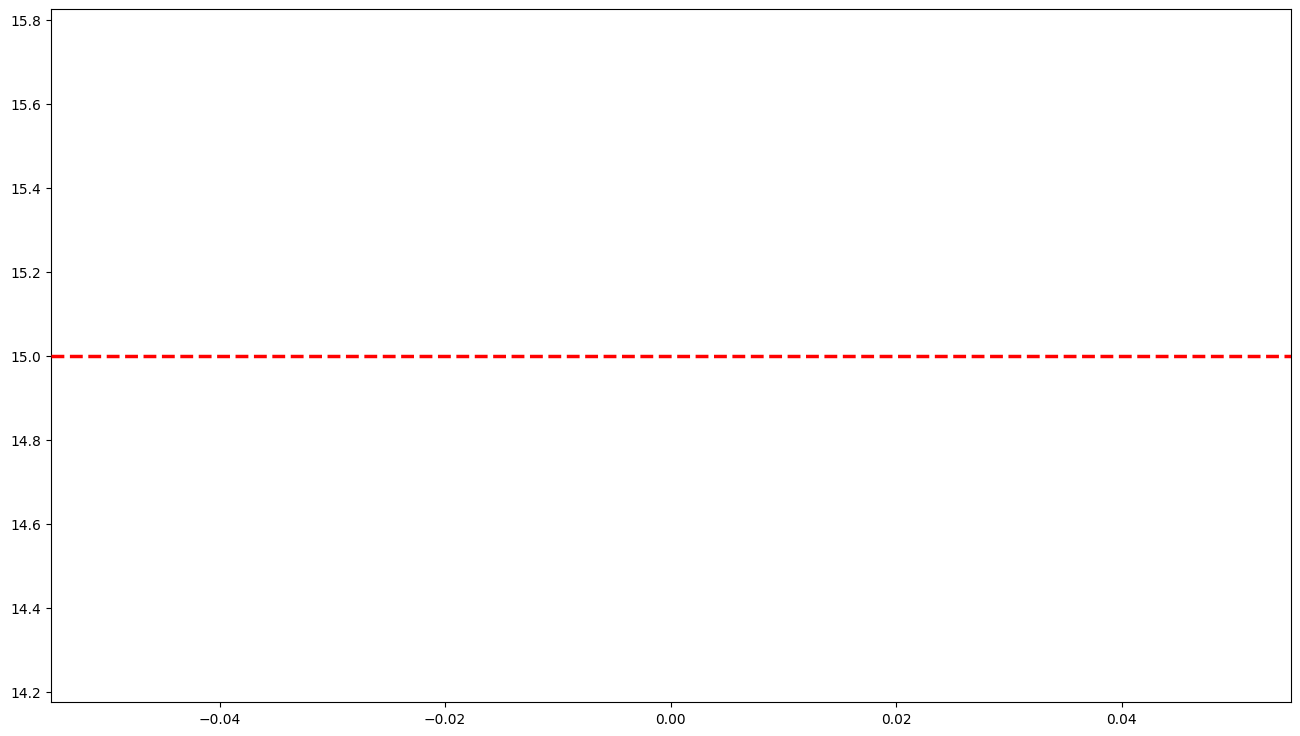

In [24]:
annual_csv_path = '../outputs/general_newsletter/annual_table.csv'

print("\n" + "="*70)
print("GENERATING ANNUAL CHARTS — GENERAL NEWSLETTER")
print("="*70 + "\n")

annual_specs = [
    ('Newsletter CVR %', t_annual_cvr,   'annual_newsletter_cvr.png', 'Annual Newsletter - CVR %'),
    ('Growth Rate',      t_annual_grow,  'annual_growth_rate.png',    'Annual Newsletter - Growth Rate'),
    ('Subscribed',       t_annual_sub,   'annual_subscribed.png',     'Annual Newsletter - Subscribed'),
    ('Unsubscribed',     t_annual_unsub, 'annual_unsubscribed.png',   'Annual Newsletter - Unsubscribed'),
    ('Leak Rate',        t_annual_leak,  'annual_leak_rate.png',      'Annual Newsletter - Leak Rate'),
]

for col, tgt, filename, title in annual_specs:
    create_annual_chart(
        csv_path=annual_csv_path,
        metric_col=col,
        target_value=tgt,
        output_path=f"{viz_annual_dir}/{filename}",
        chart_title=title,
        metric_name=col,
        start_date=ann_chart_start,
        end_date=ann_chart_end
    )


### Summary + list generated files (same as 02_newsletter)

In [25]:
print("\n" + "=" * 70)
print("VISUALIZATION GENERATION COMPLETE — GENERAL NEWSLETTER")
print("=" * 70)

weekly_charts   = len([f for f in os.listdir(viz_weekly_dir) if f.endswith('.png')])
monthly_charts  = len([f for f in os.listdir(viz_monthly_dir) if f.endswith('.png')])
quarterly_charts= len([f for f in os.listdir(viz_quarterly_dir) if f.endswith('.png')])
annual_charts   = len([f for f in os.listdir(viz_annual_dir) if f.endswith('.png')])

total_charts = weekly_charts + monthly_charts + quarterly_charts + annual_charts

print(f"\n📊 Charts Generated Summary:")
print(f"  Weekly Charts: {weekly_charts} (XmR Control Charts)")
print(f"  Monthly Charts: {monthly_charts} (Trend + Target)")
print(f"  Quarterly Charts: {quarterly_charts} (Bars + Trend + Target)")
print(f"  Annual Charts: {annual_charts} (Bars + Trend + Target)")
print(f"\n  Total Charts Generated: {total_charts}")

print(f"\n📁 Visualization Directories:")
print(f"  Weekly: {viz_weekly_dir}")
print(f"  Monthly: {viz_monthly_dir}")
print(f"  Quarterly: {viz_quarterly_dir}")
print(f"  Annual: {viz_annual_dir}")

print("\n" + "=" * 70)
print("✓ All GENERAL NEWSLETTER charts generated successfully!")
print("=" * 70 + "\n")


print("\n" + "=" * 70)
print("GENERATED CHART FILES")
print("=" * 70 + "\n")

print("WEEKLY CHARTS:")
print("-" * 70)
for file in sorted(os.listdir(viz_weekly_dir)):
    if file.endswith('.png'):
        size_kb = os.path.getsize(os.path.join(viz_weekly_dir, file)) / 1024
        print(f"  • {file:<40} ({size_kb:.1f} KB)")

print("\nMONTHLY CHARTS:")
print("-" * 70)
for file in sorted(os.listdir(viz_monthly_dir)):
    if file.endswith('.png'):
        size_kb = os.path.getsize(os.path.join(viz_monthly_dir, file)) / 1024
        print(f"  • {file:<40} ({size_kb:.1f} KB)")

print("\nQUARTERLY CHARTS:")
print("-" * 70)
for file in sorted(os.listdir(viz_quarterly_dir)):
    if file.endswith('.png'):
        size_kb = os.path.getsize(os.path.join(viz_quarterly_dir, file)) / 1024
        print(f"  • {file:<40} ({size_kb:.1f} KB)")

print("\nANNUAL CHARTS:")
print("-" * 70)
for file in sorted(os.listdir(viz_annual_dir)):
    if file.endswith('.png'):
        size_kb = os.path.getsize(os.path.join(viz_annual_dir, file)) / 1024
        print(f"  • {file:<40} ({size_kb:.1f} KB)")

print("\n" + "=" * 70)



VISUALIZATION GENERATION COMPLETE — GENERAL NEWSLETTER

📊 Charts Generated Summary:
  Weekly Charts: 5 (XmR Control Charts)
  Monthly Charts: 5 (Trend + Target)
  Quarterly Charts: 5 (Bars + Trend + Target)
  Annual Charts: 4 (Bars + Trend + Target)

  Total Charts Generated: 19

📁 Visualization Directories:
  Weekly: ../visualizations/general_newsletter_weekly
  Monthly: ../visualizations/general_newsletter_monthly
  Quarterly: ../visualizations/general_newsletter_quarterly
  Annual: ../visualizations/general_newsletter_annual

✓ All GENERAL NEWSLETTER charts generated successfully!


GENERATED CHART FILES

WEEKLY CHARTS:
----------------------------------------------------------------------
  • weekly_growth_rate.png                   (365.1 KB)
  • weekly_leak_rate.png                     (376.2 KB)
  • weekly_newsletter_cvr.png                (382.7 KB)
  • weekly_subscribed.png                    (388.5 KB)
  • weekly_unsubscribed.png                  (392.9 KB)

MONTHLY CHARTS:


#

## CUSTOM DATE RANGE ANALYSIS

### Load Custom Date Range Parameters

In [26]:
# Load analysis reference dates from CSV
ref_dates_path = Path("../analysis_ref_date.csv")

# Check if file exists
if not ref_dates_path.exists():
    print(f"❌ Error: File not found at {ref_dates_path}")
    custom_start = None
    custom_end = None
else:
    # Load reference dates
    ref_dates = pd.read_csv(ref_dates_path, header=None)
    
    # Parse custom date range
    custom_start = None
    custom_end = None
    
    for idx, row in ref_dates.iterrows():
        if row[0] == 'Custom Start Date':
            try:
                custom_start = pd.to_datetime(row[1])
            except:
                custom_start = None
        elif row[0] == 'Custom End Date':
            try:
                custom_end = pd.to_datetime(row[1])
            except:
                custom_end = None
    
    print(f"Custom Date Range:")
    print(f"  Start: {custom_start if custom_start else 'Not specified'}")
    print(f"  End: {custom_end if custom_end else 'Not specified'}")
    
    if custom_start and custom_end:
        date_range_days = (custom_end - custom_start).days + 1
        print(f"  Duration: {date_range_days} days")
    else:
        print("\n⚠️ Custom date range not properly specified in analysis_ref_date.csv")

Custom Date Range:
  Start: 2025-11-01 00:00:00
  End: 2025-11-28 00:00:00
  Duration: 28 days


### Generate Custom Date Range Table

In [27]:
print("\n" + "="*70)
print("CUSTOM DATE RANGE GENERAL NEWSLETTER AGGREGATION (WITH PREVIOUS PERIOD)")
print("="*70 + "\n")

if custom_start and custom_end:
    from dateutil.relativedelta import relativedelta
    
    # Calculate duration for display
    date_range_duration = (custom_end - custom_start).days + 1
    
    print(f"Current Period (Requested): {custom_start.strftime('%m/%d/%Y')} - {custom_end.strftime('%m/%d/%Y')} ({date_range_duration} days)")
    
    # Work with daily final data
    df_custom_prep = df_daily_final.copy()
    
    # Ensure Date is datetime
    df_custom_prep["Date"] = pd.to_datetime(df_custom_prep["Date"])
    
    # Filter data for CURRENT custom date range
    df_custom_filtered = df_custom_prep[
        (df_custom_prep["Date"] >= custom_start) & 
        (df_custom_prep["Date"] <= custom_end)
    ].copy()
    
    # Load visits data if not already loaded
    if 'df_visits' not in locals():
        df_visits = pd.read_csv(visits_path)
        df_visits["Date"] = pd.to_datetime(df_visits["Date"])
    
    # Create empty list to store rows
    custom_rows = []
    
    # Process CURRENT period
    if len(df_custom_filtered) > 0:
        # Get ACTUAL start and end dates from the current period data
        actual_current_start = df_custom_filtered["Date"].min()
        actual_current_end = df_custom_filtered["Date"].max()
        
        print(f"Current Period (Actual): {actual_current_start.strftime('%m/%d/%Y')} - {actual_current_end.strftime('%m/%d/%Y')}\n")
        
        # Get date range label using actual dates
        date_range_label = (
            actual_current_start.strftime("%m/%d/%Y")
            + " - "
            + actual_current_end.strftime("%m/%d/%Y")
        )
        
        # Sum metrics (Subscribed, Unsubscribed, Net, Posts)
        total_subscribed = df_custom_filtered["Subscribed"].sum()
        total_unsubscribed = df_custom_filtered["Unsubscribed"].sum()
        total_net = df_custom_filtered["Net"].sum()
        total_posts = df_custom_filtered["Posts"].sum()
        
        # Active Subscribers = LAST DAY in the period
        active_subscribers_last = df_custom_filtered.loc[
            df_custom_filtered["Date"].idxmax(), "Active Subscribers"
        ]
        
        # For Growth Rate and Unsub Rate, we need Active Subscribers BEFORE actual start
        df_before = df_daily_final[df_daily_final["Date"] < actual_current_start]
        if len(df_before) > 0:
            active_subscribers_prev = df_before.loc[
                df_before["Date"].idxmax(), "Active Subscribers"
            ]
        else:
            active_subscribers_prev = np.nan
        
        # Filter visits for the ACTUAL current date range
        df_visits_filtered = df_visits[
            (df_visits["Date"] >= actual_current_start) & 
            (df_visits["Date"] <= actual_current_end)
        ]
        total_visits = df_visits_filtered["Visits"].sum() if len(df_visits_filtered) > 0 else 0
        
        # Newsletter CVR % = Subscribed / Visits
        if total_visits > 0:
            newsletter_cvr = total_subscribed / total_visits
        else:
            newsletter_cvr = np.nan
        
        # Leak Rate = ABS(Unsubscribed) / Subscribed
        if total_subscribed > 0:
            leak_rate = abs(total_unsubscribed) / total_subscribed
        else:
            leak_rate = np.nan
        
        # Growth Rate = (Active_this - Active_prev) / Active_prev
        if not np.isnan(active_subscribers_prev) and active_subscribers_prev > 0:
            growth_rate = (active_subscribers_last - active_subscribers_prev) / active_subscribers_prev
        else:
            growth_rate = np.nan
        
        # Unsub Rate = ABS(Unsubscribed) / Active_prev
        if not np.isnan(active_subscribers_prev) and active_subscribers_prev > 0:
            unsub_rate = abs(total_unsubscribed) / active_subscribers_prev
        else:
            unsub_rate = np.nan
        
        # Create current row
        current_row = {
            "Date Range": date_range_label,
            "Subscribed": int(total_subscribed),
            "Unsubscribed": int(total_unsubscribed),
            "Net": int(total_net),
            "Posts": int(total_posts),
            "Active Subscribers": int(active_subscribers_last),
            "Growth Rate": growth_rate,
            "Newsletter CVR %": newsletter_cvr,
            "Leak Rate": leak_rate,
            "Unsub Rate": unsub_rate
        }
        custom_rows.append(current_row)
        
        print(f"✅ Current period data found:")
        print(f"   Duration: {(actual_current_end - actual_current_start).days + 1} days")
        print(f"   Total Subscribed: {total_subscribed:,}")
        print(f"   Total Unsubscribed: {total_unsubscribed:,}")
        print(f"   Net: {total_net:,}")
        print(f"   Total Posts: {total_posts}")
        print(f"   Active Subscribers (end): {active_subscribers_last:,}")
        
        # NOW calculate previous period based on ACTUAL current dates (shift by 1 month)
        actual_prev_start = actual_current_start - relativedelta(months=1)
        actual_prev_end = actual_current_end - relativedelta(months=1)
        
        print(f"\nPrevious Period (Calculated): {actual_prev_start.strftime('%m/%d/%Y')} - {actual_prev_end.strftime('%m/%d/%Y')}")
        
        # Filter data for PREVIOUS period using the shifted actual dates
        df_prev_filtered = df_custom_prep[
            (df_custom_prep["Date"] >= actual_prev_start) & 
            (df_custom_prep["Date"] <= actual_prev_end)
        ].copy()
        
        # Process PREVIOUS period
        if len(df_prev_filtered) > 0:
            # Get date range label
            prev_date_range_label = (
                actual_prev_start.strftime("%m/%d/%Y")
                + " - "
                + actual_prev_end.strftime("%m/%d/%Y")
            )
            
            # Sum metrics
            total_subscribed = df_prev_filtered["Subscribed"].sum()
            total_unsubscribed = df_prev_filtered["Unsubscribed"].sum()
            total_net = df_prev_filtered["Net"].sum()
            total_posts = df_prev_filtered["Posts"].sum()
            
            # Active Subscribers = LAST DAY in the period
            active_subscribers_last = df_prev_filtered.loc[
                df_prev_filtered["Date"].idxmax(), "Active Subscribers"
            ]
            
            # For Growth Rate and Unsub Rate, we need Active Subscribers BEFORE previous start
            df_before = df_daily_final[df_daily_final["Date"] < actual_prev_start]
            if len(df_before) > 0:
                active_subscribers_prev = df_before.loc[
                    df_before["Date"].idxmax(), "Active Subscribers"
                ]
            else:
                active_subscribers_prev = np.nan
            
            # Filter visits for the previous date range
            df_visits_filtered = df_visits[
                (df_visits["Date"] >= actual_prev_start) & 
                (df_visits["Date"] <= actual_prev_end)
            ]
            total_visits = df_visits_filtered["Visits"].sum() if len(df_visits_filtered) > 0 else 0
            
            # Newsletter CVR %
            if total_visits > 0:
                newsletter_cvr = total_subscribed / total_visits
            else:
                newsletter_cvr = np.nan
            
            # Leak Rate
            if total_subscribed > 0:
                leak_rate = abs(total_unsubscribed) / total_subscribed
            else:
                leak_rate = np.nan
            
            # Growth Rate
            if not np.isnan(active_subscribers_prev) and active_subscribers_prev > 0:
                growth_rate = (active_subscribers_last - active_subscribers_prev) / active_subscribers_prev
            else:
                growth_rate = np.nan
            
            # Unsub Rate
            if not np.isnan(active_subscribers_prev) and active_subscribers_prev > 0:
                unsub_rate = abs(total_unsubscribed) / active_subscribers_prev
            else:
                unsub_rate = np.nan
            
            # Create previous row
            prev_row = {
                "Date Range": prev_date_range_label,
                "Subscribed": int(total_subscribed),
                "Unsubscribed": int(total_unsubscribed),
                "Net": int(total_net),
                "Posts": int(total_posts),
                "Active Subscribers": int(active_subscribers_last),
                "Growth Rate": growth_rate,
                "Newsletter CVR %": newsletter_cvr,
                "Leak Rate": leak_rate,
                "Unsub Rate": unsub_rate
            }
            custom_rows.append(prev_row)
            
            print(f"\n✅ Previous period data found:")
            print(f"   Duration: {(actual_prev_end - actual_prev_start).days + 1} days")
            print(f"   Total Subscribed: {total_subscribed:,}")
            print(f"   Total Unsubscribed: {total_unsubscribed:,}")
            print(f"   Net: {total_net:,}")
            
        else:
            print(f"\n⚠️ No data for previous period: {actual_prev_start.strftime('%m/%d/%Y')} - {actual_prev_end.strftime('%m/%d/%Y')}")
        
    else:
        print(f"⚠️ No data for current period: {custom_start.strftime('%m/%d/%Y')} - {custom_end.strftime('%m/%d/%Y')}")
    
    # Create final dataframe
    if len(custom_rows) > 0:
        df_custom = pd.DataFrame(custom_rows)
        
        # Display the results
        print("\n" + "="*70)
        print("Custom Date Range General Newsletter Data (with Previous Period):")
        print("="*70)
        display(df_custom)
        
    else:
        print("\n⚠️ No data available for either current or previous period")
        df_custom = None
        
else:
    print("❌ Cannot generate custom analysis - dates not properly specified")
    print("   Please check Custom Start Date and Custom End Date in analysis_ref_date.csv")
    df_custom = None

print("\n" + "="*70)


CUSTOM DATE RANGE GENERAL NEWSLETTER AGGREGATION (WITH PREVIOUS PERIOD)

Current Period (Requested): 11/01/2025 - 11/28/2025 (28 days)
Current Period (Actual): 11/01/2025 - 11/28/2025

✅ Current period data found:
   Duration: 28 days
   Total Subscribed: 16,289
   Total Unsubscribed: -10,279
   Net: 6,010
   Total Posts: 30
   Active Subscribers (end): 164,354

Previous Period (Calculated): 10/01/2025 - 10/28/2025

✅ Previous period data found:
   Duration: 28 days
   Total Subscribed: 11,488
   Total Unsubscribed: -8,640
   Net: 2,848

Custom Date Range General Newsletter Data (with Previous Period):


,Date Range,Subscribed,Unsubscribed,Net,Posts,Active Subscribers,Growth Rate,Newsletter CVR %,Leak Rate,Unsub Rate
0,11/01/2025 - 11/28/2025,16289,-10279,6010,30,164354,0.036188,0.135242,0.631039,0.064805
1,10/01/2025 - 10/28/2025,11488,-8640,2848,37,158149,0.017356,0.190063,0.752089,0.055580


### Save Custom Date Range Data

In [28]:
if df_custom is not None and len(df_custom) > 0:
    # Save to CSV
    custom_path = out_dir / "custom_table.csv"
    df_custom.to_csv(custom_path, index=False)
    
    print("\n" + "="*70)
    print("CUSTOM DATE RANGE ANALYSIS - COMPLETE")
    print("="*70)
    
    print(f"\n✅ OUTPUT CREATED:")
    print(f"  - custom_table.csv")
    
    print(f"\n📁 Saved in:")
    print(f"  - {custom_path}")
    
    print(f"\n📊 File Details:")
    print(f"  - Shape: {df_custom.shape[0]} rows × {df_custom.shape[1]} columns")
    print(f"  - Rows: {len(df_custom)} (current + previous period)")
    
    print(f"\n📈 Columns:")
    print(f"  - Date Range")
    print(f"  - Subscribed, Unsubscribed, Net, Posts")
    print(f"  - Active Subscribers, Growth Rate")
    print(f"  - Newsletter CVR %, Leak Rate, Unsub Rate")
    
    print("\n" + "="*70)
else:
    print("\n⚠️ Custom analysis not saved - no data to save")
    print("   Check date range and data availability")


CUSTOM DATE RANGE ANALYSIS - COMPLETE

✅ OUTPUT CREATED:
  - custom_table.csv

📁 Saved in:
  - ../outputs/general_newsletter/custom_table.csv

📊 File Details:
  - Shape: 2 rows × 10 columns
  - Rows: 2 (current + previous period)

📈 Columns:
  - Date Range
  - Subscribed, Unsubscribed, Net, Posts
  - Active Subscribers, Growth Rate
  - Newsletter CVR %, Leak Rate, Unsub Rate



### Verification - Preview Custom Date Range File

In [29]:
if df_custom is not None and len(df_custom) > 0:
    print("Custom Date Range General Newsletter Preview:")
    print("="*70)
    display(df_custom)
    
    print(f"\n✓ Custom date range analysis completed successfully!")
    print(f"  File location: {out_dir / 'custom_table.csv'}")
else:
    print("⚠️ No custom data available to preview")

Custom Date Range General Newsletter Preview:


,Date Range,Subscribed,Unsubscribed,Net,Posts,Active Subscribers,Growth Rate,Newsletter CVR %,Leak Rate,Unsub Rate
0,11/01/2025 - 11/28/2025,16289,-10279,6010,30,164354,0.036188,0.135242,0.631039,0.064805
1,10/01/2025 - 10/28/2025,11488,-8640,2848,37,158149,0.017356,0.190063,0.752089,0.055580



✓ Custom date range analysis completed successfully!
  File location: ../outputs/general_newsletter/custom_table.csv
